# Hospital Readmission Penalties Analysis

Looking at CMS data to figure out which hospitals are getting penalized for readmissions and why.

Medicare penalizes hospitals up to 3% of their payments if too many patients come back within 30 days. This project uses 3 real government datasets from data.cms.gov to analyze the patterns.

**datasets:**
- Hospital Readmissions Reduction Program (HRRP) - has the excess readmission ratios by condition
- Unplanned Hospital Visits - actual readmission rates + comparison to national avg
- Hospital General Information - hospital type, ownership, star ratings etc

In [49]:
import pandas as pd
import sqlite3
import os

conn = sqlite3.connect('hospital_readmissions.db')
cursor = conn.cursor()

## loading raw data into sqlite
reading everything as strings first bc CMS puts "Not Available" in numeric columns and it breaks pandas if you dont

In [50]:
os.listdir('data/raw/')

['FY_2026_Hospital_Readmissions_Reduction_Program_Hospital.csv',
 '.DS_Store',
 'Unplanned_Hospital_Visits-Hospital.csv',
 'Hospital_General_Information.csv']

In [51]:
# load all 3 csvs into sqlite as raw tables
# dtype=str so nothing breaks from the messy values

df1 = pd.read_csv('data/raw/Hospital_General_Information.csv', dtype=str)
df1.to_sql('raw_hospital_info', conn, if_exists='replace', index=False)

df2 = pd.read_csv('data/raw/FY_2026_Hospital_Readmissions_Reduction_Program_Hospital.csv', dtype=str)
df2.to_sql('raw_hrrp', conn, if_exists='replace', index=False)

df3 = pd.read_csv('data/raw/Unplanned_Hospital_Visits-Hospital.csv', dtype=str)
df3.to_sql('raw_unplanned_visits', conn, if_exists='replace', index=False)

print(f'hospital info: {len(df1)} rows')
print(f'hrrp: {len(df2)} rows')
print(f'unplanned visits: {len(df3)} rows')

hospital info: 5426 rows
hrrp: 18330 rows
unplanned visits: 67046 rows


## exploring the raw data
gotta see whats actually in these tables before i start cleaning

In [52]:
pd.read_sql("SELECT * FROM raw_hospital_info LIMIT 5", conn)

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,0,11,0,None,8,8,None,12,11,None
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,0,8,1,None,8,8,None,12,12,None
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,0,8,1,None,8,8,None,12,10,None
3,010007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,Acute Care Hospitals,Voluntary non-profit - Private,...,0,7,0,None,8,8,None,12,7,None
4,010008,CRENSHAW COMMUNITY HOSPITAL,101 HOSPITAL CIRCLE,LUVERNE,AL,36049,CRENSHAW,(334) 335-3374,Acute Care Hospitals,Proprietary,...,0,2,0,None,8,Not Available,5,12,6,None


In [53]:
pd.read_sql("SELECT * FROM raw_hrrp LIMIT 5", conn)

,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-HIP-KNEE-HRRP,None,None,0.9875,4.5734,4.6311,Too Few to Report,07/01/2021,06/30/2024
1,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-CABG-HRRP,137,None,0.9531,10.3960,10.9078,13,07/01/2021,06/30/2024
2,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-AMI-HRRP,273,None,0.9370,13.2998,14.1948,33,07/01/2021,06/30/2024
3,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-COPD-HRRP,122,None,0.9823,16.6384,16.9389,19,07/01/2021,06/30/2024
4,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-PN-HRRP,507,None,0.9871,15.7529,15.9591,79,07/01/2021,06/30/2024


In [54]:
pd.read_sql("SELECT * FROM raw_unplanned_visits LIMIT 5", conn)

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Measure ID,Measure Name,Compared to National,Denominator,Score,Lower Estimate,Higher Estimate,Number of Patients,Number of Patients Returned,Footnote,Start Date,End Date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_AMI,Hospital return days for heart attack patients,Fewer Days Than Average per 100 Discharges,273,-15.6,-25.9,-4.2,264,68,None,07/01/2021,06/30/2024
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_HF,Hospital return days for heart failure patients,Average Days per 100 Discharges,652,-1.1,-10,7.9,541,186,None,07/01/2021,06/30/2024
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_PN,Hospital return days for pneumonia patients,More Days Than Average per 100 Discharges,507,17.4,8.2,27.5,471,114,None,07/01/2021,06/30/2024
3,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Hybrid_HWR,Hybrid Hospital-Wide All-Cause Readmission Mea...,No Different Than the National Rate,2824,15.1,13.2,17.2,Not Applicable,Not Applicable,None,07/01/2023,06/30/2024
4,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,OP_32,Rate of unplanned hospital visits after colono...,No Different Than the National Rate,234,12.7,9.5,17,Not Applicable,Not Applicable,None,01/01/2022,12/31/2024


In [55]:
# the unplanned visits file has a ton of different measures mixed together
# need to figure out which ones are the readmission measures
pd.read_sql("""
    SELECT [Measure ID], COUNT(*) as cnt 
    FROM raw_unplanned_visits 
    GROUP BY [Measure ID]
""", conn)

,Measure ID,cnt
0,EDAC_30_AMI,4789
1,EDAC_30_HF,4789
2,EDAC_30_PN,4789
3,Hybrid_HWR,4789
4,OP_32,4789
5,OP_35_ADM,4789
6,OP_35_ED,4789
7,OP_36,4789
8,READM_30_AMI,4789
9,READM_30_CABG,4789


ok so theres 14 different measure types. I only want the READM_30 ones (6 of them) for this analysis. the EDAC ones are about excess days in acute care and OP ones are outpatient - dont need those.

In [56]:
# checking column names so i know what to reference in SQL
print("HRRP columns:")
display(pd.read_sql("PRAGMA table_info(raw_hrrp)", conn))
print("\nUnplanned visits columns:")
display(pd.read_sql("PRAGMA table_info(raw_unplanned_visits)", conn))

HRRP columns:


,cid,name,type,notnull,dflt_value,pk
0,0,Facility Name,TEXT,0,None,0
1,1,Facility ID,TEXT,0,None,0
2,2,State,TEXT,0,None,0
3,3,Measure Name,TEXT,0,None,0
4,4,Number of Discharges,TEXT,0,None,0
5,5,Footnote,TEXT,0,None,0
6,6,Excess Readmission Ratio,TEXT,0,None,0
7,7,Predicted Readmission Rate,TEXT,0,None,0
8,8,Expected Readmission Rate,TEXT,0,None,0
9,9,Number of Readmissions,TEXT,0,None,0



Unplanned visits columns:


,cid,name,type,notnull,dflt_value,pk
0,0,Facility ID,TEXT,0,None,0
1,1,Facility Name,TEXT,0,None,0
2,2,Address,TEXT,0,None,0
3,3,City/Town,TEXT,0,None,0
4,4,State,TEXT,0,None,0
5,5,ZIP Code,TEXT,0,None,0
6,6,County/Parish,TEXT,0,None,0
7,7,Telephone Number,TEXT,0,None,0
8,8,Measure ID,TEXT,0,None,0
9,9,Measure Name,TEXT,0,None,0


In [57]:
# how much data is actually usable vs missing/messy?

# HRRP - checking for null ERR values
pd.read_sql("""
    SELECT [Excess Readmission Ratio], COUNT(*) as cnt
    FROM raw_hrrp
    WHERE [Excess Readmission Ratio] IS NULL 
       OR [Excess Readmission Ratio] = 'Not Available'
       OR [Excess Readmission Ratio] = ''
    GROUP BY [Excess Readmission Ratio]
""", conn)

,Excess Readmission Ratio,cnt
0,None,6610


In [58]:
# unplanned visits - checking messy Score values
pd.read_sql("""
    SELECT Score, COUNT(*) as cnt
    FROM raw_unplanned_visits
    WHERE Score = 'Not Available' 
       OR Score = 'Too Few to Report'
       OR Score IS NULL
    GROUP BY Score
""", conn)

,Score,cnt
0,Not Available,31766


In [59]:
# how many hospitals in each table?
# important to check bc not all hospitals will be in all 3 files
pd.read_sql("""
    SELECT 'hospital_info' as tbl, COUNT(DISTINCT [Facility ID]) as cnt FROM raw_hospital_info
    UNION ALL
    SELECT 'hrrp', COUNT(DISTINCT [Facility ID]) FROM raw_hrrp
    UNION ALL
    SELECT 'unplanned_visits', COUNT(DISTINCT [Facility ID]) FROM raw_unplanned_visits
""", conn)

,tbl,cnt
0,hospital_info,5426
1,hrrp,3055
2,unplanned_visits,4789


5426 hospitals in the info table but only 3055 in HRRP. Makes sense - Critical Access Hospitals and Childrens hospitals arent in the penalty program. Only acute care hospitals get penalized.

In [60]:
# how much usable data per readmission measure?
pd.read_sql("""
    SELECT [Measure ID],
           COUNT(*) as total,
           SUM(CASE WHEN Score != 'Not Available' AND Score IS NOT NULL THEN 1 ELSE 0 END) as has_data,
           SUM(CASE WHEN Score = 'Not Available' OR Score IS NULL THEN 1 ELSE 0 END) as missing
    FROM raw_unplanned_visits
    WHERE [Measure ID] LIKE 'READM_30%'
    GROUP BY [Measure ID]
""", conn)

,Measure ID,total,has_data,missing
0,READM_30_AMI,4789,1825,2964
1,READM_30_CABG,4789,878,3911
2,READM_30_COPD,4789,2699,2090
3,READM_30_HF,4789,3155,1634
4,READM_30_HIP_KNEE,4789,1625,3164
5,READM_30_PN,4789,3638,1151


Heart Failure has the most data (3155 hospitals), CABG has the least (878). CABG is missing so much because not every hospital does bypass surgery. Plenty of data to work with though.

## cleaning the data
main issues to fix:
- "Not Available" and None strings in numeric columns -> need to convert to actual NULLs
- cast ERR, discharges etc from text to real numbers
- filter unplanned visits to only the 6 READM measures (not ED visits etc)
- create ownership categories (the raw data has like 9 different types)

In [61]:
# clean HRRP table
# the main thing is converting ERR from text to float and handling the nulls
cursor.execute("DROP TABLE IF EXISTS clean_hrrp")
cursor.execute("""
    CREATE TABLE clean_hrrp AS
    SELECT 
        [Facility ID],
        [Facility Name],
        State,
        [Measure Name],
        CASE 
            WHEN [Excess Readmission Ratio] IS NULL THEN NULL
            WHEN [Excess Readmission Ratio] = '' THEN NULL
            ELSE CAST([Excess Readmission Ratio] AS REAL)
        END as excess_readmission_ratio,
        CASE
            WHEN [Number of Discharges] IS NULL THEN NULL
            WHEN [Number of Discharges] = '' THEN NULL
            ELSE CAST([Number of Discharges] AS INTEGER)
        END as num_discharges,
        CASE
            WHEN [Number of Readmissions] IS NULL THEN NULL
            ELSE CAST([Number of Readmissions] AS INTEGER)
        END as num_readmissions
    FROM raw_hrrp
""")
conn.commit()

pd.read_sql("SELECT * FROM clean_hrrp LIMIT 5", conn)

,Facility ID,Facility Name,State,Measure Name,excess_readmission_ratio,num_discharges,num_readmissions
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-HIP-KNEE-HRRP,0.9875,NaN,0
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-CABG-HRRP,0.9531,137.0,13
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-AMI-HRRP,0.9370,273.0,33
3,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-COPD-HRRP,0.9823,122.0,19
4,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-PN-HRRP,0.9871,507.0,79


In [62]:
# clean hospital info
# converting star rating to int and grouping ownership into simpler categories
cursor.execute("DROP TABLE IF EXISTS clean_hospital_info")
cursor.execute("""
    CREATE TABLE clean_hospital_info AS
    SELECT 
        [Facility ID],
        [Facility Name],
        [City/Town] as city,
        State,
        [ZIP Code],
        [County/Parish] as county,
        [Hospital Type],
        [Hospital Ownership],
        [Emergency Services],
        CASE 
            WHEN [Hospital overall rating] = 'Not Available' THEN NULL
            WHEN [Hospital overall rating] IS NULL THEN NULL
            ELSE CAST([Hospital overall rating] AS INTEGER)
        END as overall_rating,
        CASE
            WHEN [Hospital Ownership] LIKE '%non-profit%' THEN 'Non-Profit'
            WHEN [Hospital Ownership] LIKE '%Proprietary%' THEN 'For-Profit'
            WHEN [Hospital Ownership] LIKE '%Government%' THEN 'Government'
            WHEN [Hospital Ownership] LIKE '%Tribal%' THEN 'Tribal'
            ELSE 'Other'
        END as ownership_category
    FROM raw_hospital_info
""")
conn.commit()

pd.read_sql("SELECT * FROM clean_hospital_info LIMIT 5", conn)

,Facility ID,Facility Name,city,State,ZIP Code,county,Hospital Type,Hospital Ownership,Emergency Services,overall_rating,ownership_category
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,36301,HOUSTON,Acute Care Hospitals,Government - Hospital District or Authority,Yes,4.0,Government
1,010005,MARSHALL MEDICAL CENTERS,BOAZ,AL,35957,MARSHALL,Acute Care Hospitals,Government - Hospital District or Authority,Yes,3.0,Government
2,010006,NORTH ALABAMA MEDICAL CENTER,FLORENCE,AL,35630,LAUDERDALE,Acute Care Hospitals,Proprietary,Yes,2.0,For-Profit
3,010007,MIZELL MEMORIAL HOSPITAL,OPP,AL,36467,COVINGTON,Acute Care Hospitals,Voluntary non-profit - Private,Yes,1.0,Non-Profit
4,010008,CRENSHAW COMMUNITY HOSPITAL,LUVERNE,AL,36049,CRENSHAW,Acute Care Hospitals,Proprietary,Yes,NaN,For-Profit


In [63]:
# clean unplanned visits
# IMPORTANT: only keeping READM_30 measures, not ED visits or other stuff
cursor.execute("DROP TABLE IF EXISTS clean_readmissions")
cursor.execute("""
    CREATE TABLE clean_readmissions AS
    SELECT 
        [Facility ID],
        [Facility Name],
        State,
        [Measure ID],
        [Measure Name],
        CASE 
            WHEN Score = 'Not Available' THEN NULL
            WHEN Score IS NULL THEN NULL
            ELSE CAST(Score AS REAL)
        END as readmission_rate,
        CASE 
            WHEN Denominator = 'Not Available' THEN NULL
            WHEN Denominator IS NULL THEN NULL
            ELSE CAST(Denominator AS INTEGER)
        END as num_discharges,
        [Compared to National]
    FROM raw_unplanned_visits
    WHERE [Measure ID] LIKE 'READM_30%'
""")
conn.commit()

pd.read_sql("SELECT * FROM clean_readmissions LIMIT 5", conn)

,Facility ID,Facility Name,State,Measure ID,Measure Name,readmission_rate,num_discharges,Compared to National
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM_30_AMI,Acute Myocardial Infarction (AMI) 30-Day Readm...,13.0,273,No Different Than the National Rate
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM_30_CABG,Rate of readmission for CABG,10.1,137,No Different Than the National Rate
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM_30_COPD,Rate of readmission for chronic obstructive pu...,18.0,122,No Different Than the National Rate
3,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM_30_HF,Heart failure (HF) 30-Day Readmission Rate,20.1,652,No Different Than the National Rate
4,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM_30_HIP_KNEE,Rate of readmission after hip/knee replacement,4.8,25,No Different Than the National Rate


## joining tables
merging hospital info with HRRP data on Facility ID to create one master table

In [64]:
# master table - hospital characteristics + readmission data
# using INNER JOIN so we only get hospitals that are in both tables
cursor.execute("DROP TABLE IF EXISTS master_hospital")
cursor.execute("""
    CREATE TABLE master_hospital AS
    SELECT 
        h.[Facility ID],
        h.[Facility Name],
        h.city,
        h.State,
        h.county,
        h.[Hospital Type],
        h.[Hospital Ownership],
        h.ownership_category,
        h.overall_rating,
        h.[Emergency Services],
        p.[Measure Name] as condition,
        p.excess_readmission_ratio,
        p.num_discharges,
        p.num_readmissions
    FROM clean_hospital_info h
    INNER JOIN clean_hrrp p ON h.[Facility ID] = p.[Facility ID]
""")
conn.commit()

pd.read_sql("""
    SELECT COUNT(*) as total_rows, 
           COUNT(DISTINCT [Facility ID]) as unique_hospitals
    FROM master_hospital
""", conn)

,total_rows,unique_hospitals
0,18330,3055


3055 hospitals x 6 conditions = ~18330 rows. looks right.

---
## Analysis
now the actual interesting part

### Q1: which conditions have the highest excess readmissions?

In [65]:
pd.read_sql("""
    SELECT condition,
           COUNT(*) as hospitals_with_data,
           ROUND(AVG(excess_readmission_ratio), 4) as avg_err,
           SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) as num_above_expected,
           ROUND(100.0 * SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) / COUNT(*), 1) as pct_above
    FROM master_hospital
    WHERE excess_readmission_ratio IS NOT NULL
    GROUP BY condition
    ORDER BY avg_err DESC
""", conn)

,condition,hospitals_with_data,avg_err,num_above_expected,pct_above
0,READM-30-HIP-KNEE-HRRP,1447,1.0040,693,47.9
1,READM-30-CABG-HRRP,878,1.0018,438,49.9
2,READM-30-AMI-HRRP,1736,1.0018,862,49.7
3,READM-30-PN-HRRP,2715,1.0015,1271,46.8
4,READM-30-HF-HRRP,2621,1.0014,1282,48.9
5,READM-30-COPD-HRRP,2323,1.0011,1097,47.2


### Q2: do for-profit hospitals get penalized more?

In [66]:
pd.read_sql("""
    SELECT ownership_category,
           COUNT(DISTINCT [Facility ID]) as num_hospitals,
           ROUND(AVG(excess_readmission_ratio), 4) as avg_err,
           SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) as excess_count
    FROM master_hospital
    WHERE excess_readmission_ratio IS NOT NULL
    GROUP BY ownership_category
    ORDER BY avg_err DESC
""", conn)

,ownership_category,num_hospitals,avg_err,excess_count
0,For-Profit,551,1.0174,1156
1,Government,393,1.0012,732
2,Non-Profit,1831,0.9984,3718
3,Tribal,4,0.9811,2
4,Other,54,0.9493,35


yeah for-profit hospitals have the highest avg ERR (1.0174). non-profits are actually below expected at 0.9984. thats a noticeable difference.

### Q3: star rating vs readmission performance

In [67]:
pd.read_sql("""
    SELECT overall_rating,
           COUNT(DISTINCT [Facility ID]) as num_hospitals,
           ROUND(AVG(excess_readmission_ratio), 4) as avg_err,
           SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) as excess_count
    FROM master_hospital
    WHERE overall_rating IS NOT NULL
      AND excess_readmission_ratio IS NOT NULL
    GROUP BY overall_rating
    ORDER BY overall_rating
""", conn)

,overall_rating,num_hospitals,avg_err,excess_count
0,1,208,1.0415,613
1,2,601,1.0197,1551
2,3,819,1.0060,1818
3,4,655,0.9831,1137
4,5,211,0.9661,296


clear gradient here:
- 1-star hospitals: avg ERR 1.0415 (way above expected)
- 5-star hospitals: avg ERR 0.9661 (well below expected)

so lower rated hospitals definitely have worse readmission rates

### Q4: worst offenders - hospitals failing on multiple conditions

In [68]:
# hospitals with excess readmissions in 4+ conditions out of 6
pd.read_sql("""
    SELECT [Facility ID], 
           [Facility Name], 
           State, 
           ownership_category,
           overall_rating,
           COUNT(*) as conditions_measured,
           SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) as conditions_above_expected,
           ROUND(AVG(excess_readmission_ratio), 4) as avg_err
    FROM master_hospital
    WHERE excess_readmission_ratio IS NOT NULL
    GROUP BY [Facility ID], [Facility Name], State, ownership_category, overall_rating
    HAVING conditions_above_expected >= 4
    ORDER BY conditions_above_expected DESC, avg_err DESC
    LIMIT 15
""", conn)

,Facility ID,Facility Name,State,ownership_category,overall_rating,conditions_measured,conditions_above_expected,avg_err
0,100007,ADVENTHEALTH ORLANDO,FL,Non-Profit,3,6,6,1.1426
1,220116,TUFTS MEDICAL CENTER,MA,Non-Profit,3,6,6,1.1393
2,230041,MCLAREN BAY REGION,MI,Non-Profit,2,6,6,1.1384
3,100238,HCA FLORIDA NORTHSIDE HOSPITAL,FL,For-Profit,1,6,6,1.1360
4,220012,CAPE COD HOSPITAL,MA,Non-Profit,3,6,6,1.1155
5,390115,JEFFERSON HEALTH- NORTHEAST,PA,Non-Profit,1,6,6,1.1096
6,240053,PARK NICOLLET METHODIST HOSPITAL,MN,Non-Profit,3,6,6,1.1031
7,040027,BAXTER HEALTH,AR,Non-Profit,1,6,6,1.0998
8,230141,MCLAREN FLINT,MI,Non-Profit,1,6,6,1.0906
9,490048,LEWISGALE MEDICAL CENTER,VA,For-Profit,2,6,6,1.0814


### Q5: state level comparison

In [69]:
# which states have the worst readmission rates?
pd.read_sql("""
    SELECT State,
           COUNT(DISTINCT [Facility ID]) as num_hospitals,
           ROUND(AVG(excess_readmission_ratio), 4) as avg_err,
           SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) as num_excess
    FROM master_hospital
    WHERE excess_readmission_ratio IS NOT NULL
    GROUP BY State
    ORDER BY avg_err DESC
    LIMIT 15
""", conn)

,State,num_hospitals,avg_err,num_excess
0,MA,52,1.0344,150
1,NJ,61,1.0277,178
2,FL,164,1.0229,443
3,IL,109,1.0194,284
4,MS,50,1.0141,113
5,AL,67,1.0139,130
6,WV,22,1.0115,51
7,NV,19,1.0114,48
8,GA,88,1.0114,193
9,KY,59,1.0101,123


---
## Visualizations

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('charts', exist_ok=True)

# pull everything into pandas for the charts
master = pd.read_sql("SELECT * FROM master_hospital", conn)

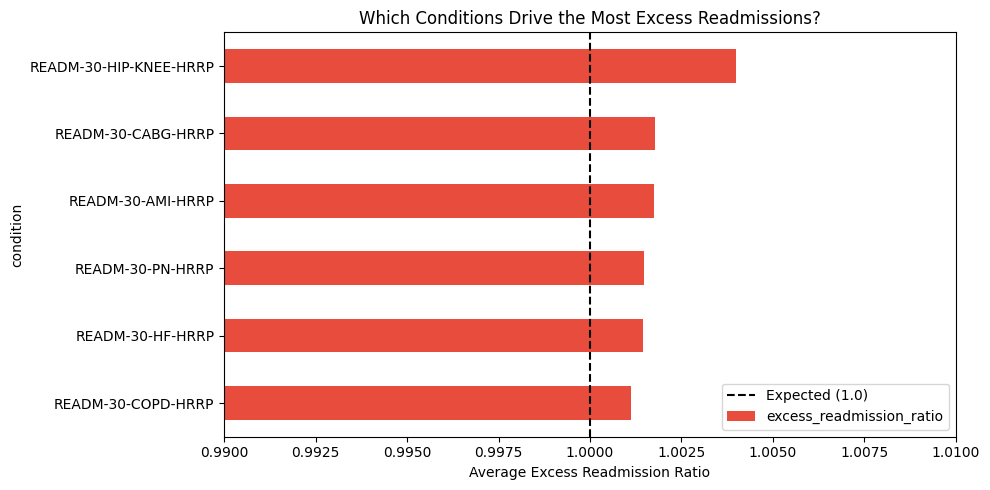

In [71]:
# chart 1: avg ERR by condition
# had to set xlim to zoom in bc the values are all so close to 1.0
condition_stats = master[master['excess_readmission_ratio'].notna()].groupby('condition')['excess_readmission_ratio'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if x > 1.0 else '#3498db' for x in condition_stats.values]
condition_stats.plot(kind='barh', ax=ax, color=colors)
ax.axvline(x=1.0, color='black', linestyle='--', label='Expected (1.0)')
ax.set_xlim(0.99, 1.01)
ax.set_xlabel('Average Excess Readmission Ratio')
ax.set_title('Which Conditions Drive the Most Excess Readmissions?')
ax.legend()
plt.tight_layout()
plt.savefig('charts/01_conditions_err.png', dpi=150)
plt.show()

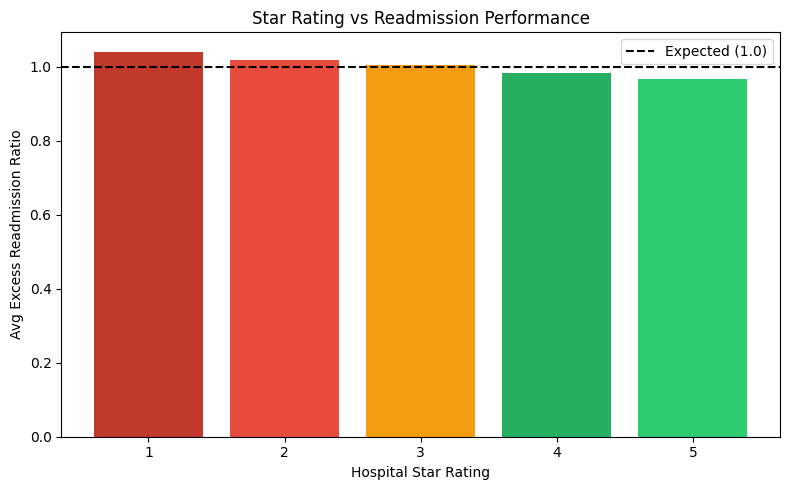

In [72]:
# chart 2: star rating vs avg ERR
# the gradient is really clear here - lower stars = worse readmissions
star_data = master[master['overall_rating'].notna() & master['excess_readmission_ratio'].notna()]
star_stats = star_data.groupby('overall_rating')['excess_readmission_ratio'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(star_stats.index, star_stats.values, 
       color=['#c0392b', '#e74c3c', '#f39c12', '#27ae60', '#2ecc71'])
ax.axhline(y=1.0, color='black', linestyle='--', label='Expected (1.0)')
ax.set_xlabel('Hospital Star Rating')
ax.set_ylabel('Avg Excess Readmission Ratio')
ax.set_title('Star Rating vs Readmission Performance')
ax.legend()
plt.tight_layout()
plt.savefig('charts/02_star_vs_err.png', dpi=150)
plt.show()

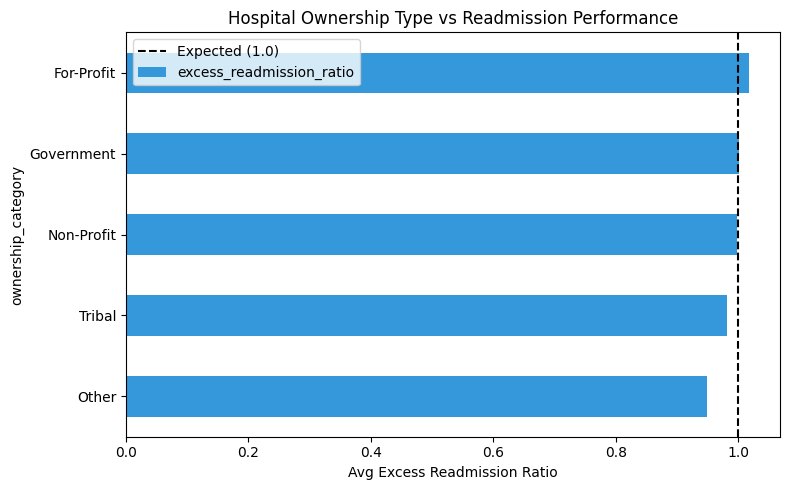

In [73]:
# chart 3: ownership type comparison
own_stats = master[master['excess_readmission_ratio'].notna()].groupby('ownership_category')['excess_readmission_ratio'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
own_stats.plot(kind='barh', ax=ax, color='#3498db')
ax.axvline(x=1.0, color='black', linestyle='--', label='Expected (1.0)')
ax.set_xlabel('Avg Excess Readmission Ratio')
ax.set_title('Hospital Ownership Type vs Readmission Performance')
ax.legend()
plt.tight_layout()
plt.savefig('charts/03_ownership_err.png', dpi=150)
plt.show()

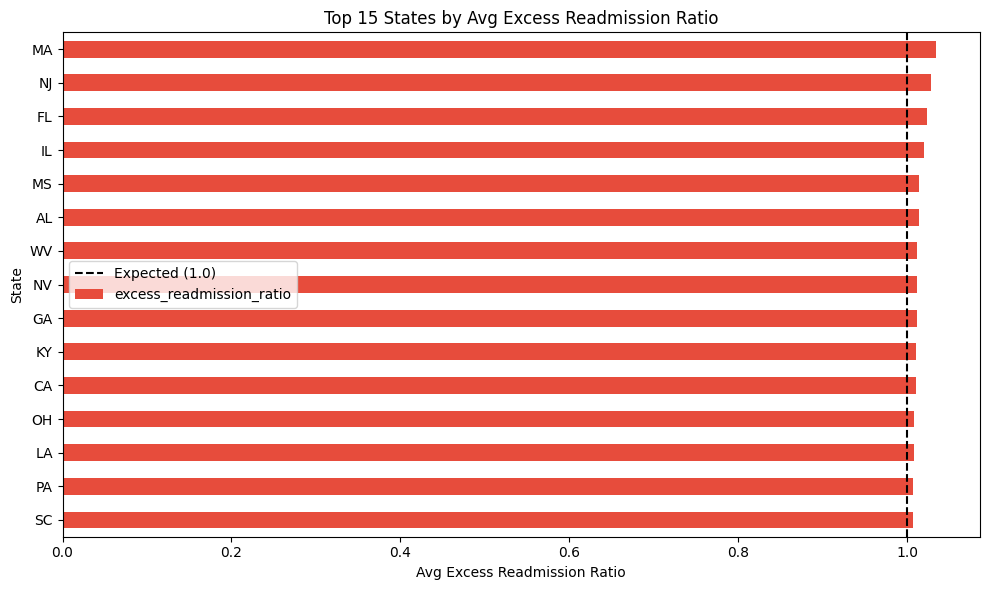

In [74]:
# chart 4: top 15 states
state_stats = master[master['excess_readmission_ratio'].notna()].groupby('State')['excess_readmission_ratio'].mean().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
state_stats.sort_values(ascending=True).plot(kind='barh', ax=ax, color='#e74c3c')
ax.axvline(x=1.0, color='black', linestyle='--', label='Expected (1.0)')
ax.set_xlabel('Avg Excess Readmission Ratio')
ax.set_title('Top 15 States by Avg Excess Readmission Ratio')
ax.legend()
plt.tight_layout()
plt.savefig('charts/04_top_states.png', dpi=150)
plt.show()

/var/folders/9v/m7xlhp3j2cz1nmdxztqqdw200000gn/T/ipykernel_14221/3317499692.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='condition', y='excess_readmission_ratio', palette='Set2', ax=ax)


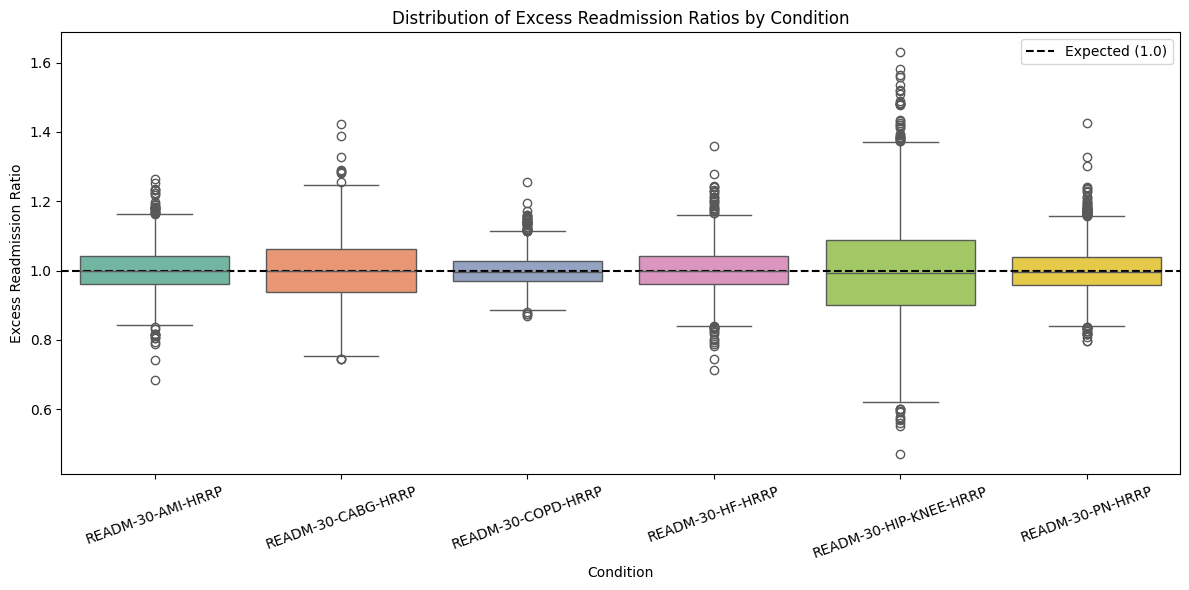

In [75]:
# chart 5: boxplot of ERR by condition
# shows the full spread not just the average
fig, ax = plt.subplots(figsize=(12, 6))
plot_data = master[master['excess_readmission_ratio'].notna()]
sns.boxplot(data=plot_data, x='condition', y='excess_readmission_ratio', palette='Set2', ax=ax)
ax.axhline(y=1.0, color='black', linestyle='--', label='Expected (1.0)')
ax.set_xlabel('Condition')
ax.set_ylabel('Excess Readmission Ratio')
ax.set_title('Distribution of Excess Readmission Ratios by Condition')
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('charts/05_err_boxplot.png', dpi=150)
plt.show()

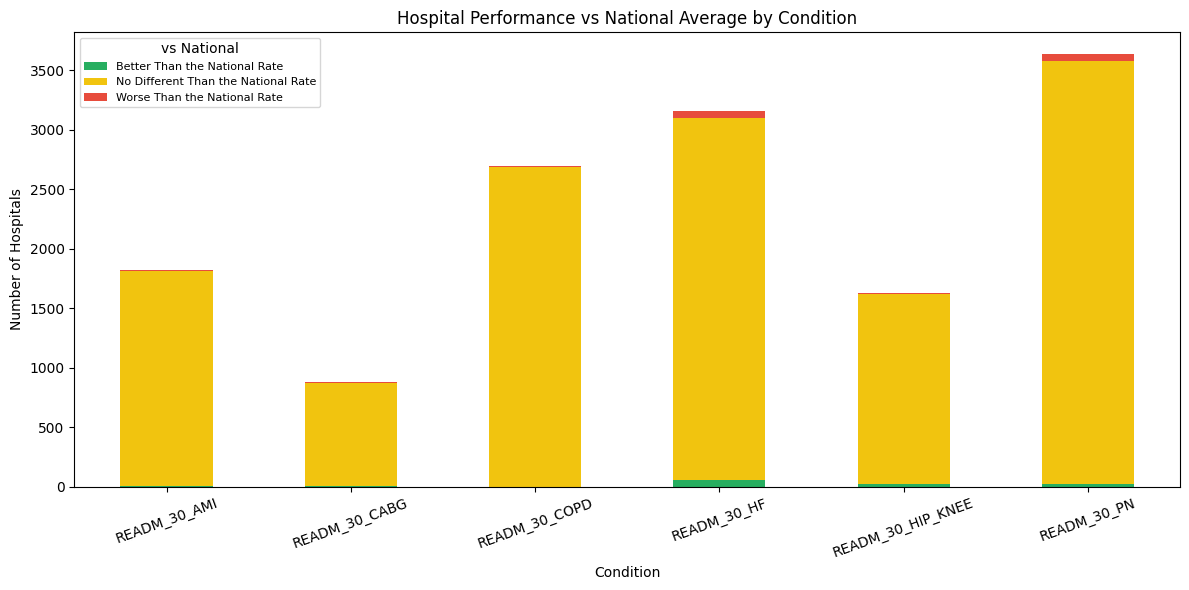

In [76]:
# chart 6: performance vs national average (from the unplanned visits data)
readmissions = pd.read_sql("""
    SELECT [Measure ID], [Compared to National], COUNT(*) as cnt
    FROM clean_readmissions
    WHERE readmission_rate IS NOT NULL
    GROUP BY [Measure ID], [Compared to National]
""", conn)

fig, ax = plt.subplots(figsize=(12, 6))
pivot = readmissions.pivot(index='Measure ID', columns='Compared to National', values='cnt').fillna(0)
pivot.plot(kind='bar', stacked=True, ax=ax, color=['#27ae60', '#f1c40f', '#e74c3c'])
ax.set_xlabel('Condition')
ax.set_ylabel('Number of Hospitals')
ax.set_title('Hospital Performance vs National Average by Condition')
ax.legend(title='vs National', fontsize=8)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('charts/06_vs_national.png', dpi=150)
plt.show()

/var/folders/9v/m7xlhp3j2cz1nmdxztqqdw200000gn/T/ipykernel_14221/3152303453.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hospital_fails = master[master['excess_readmission_ratio'].notna()].groupby('Facility ID').apply(


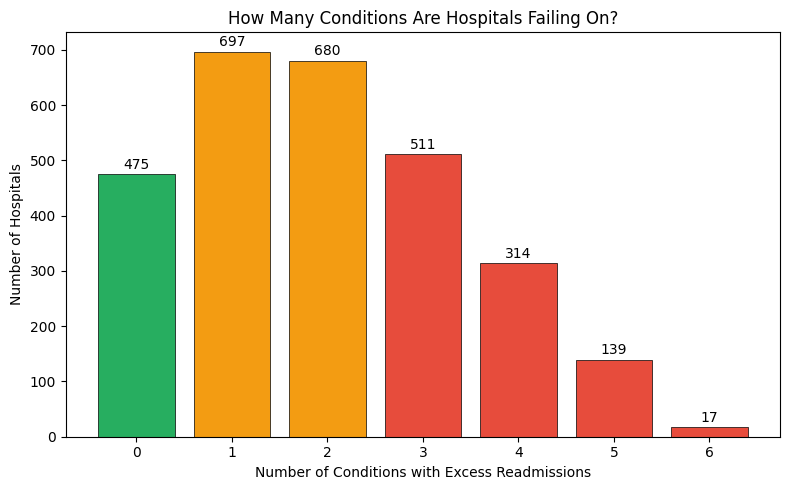

In [77]:
# chart 7: how many conditions are hospitals failing on?
hospital_fails = master[master['excess_readmission_ratio'].notna()].groupby('Facility ID').apply(
    lambda x: (x['excess_readmission_ratio'] > 1.0).sum()
).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#27ae60' if x == 0 else '#f39c12' if x <= 2 else '#e74c3c' for x in hospital_fails.index]
ax.bar(hospital_fails.index, hospital_fails.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Number of Conditions with Excess Readmissions')
ax.set_ylabel('Number of Hospitals')
ax.set_title('How Many Conditions Are Hospitals Failing On?')
for x, y in zip(hospital_fails.index, hospital_fails.values):
    ax.text(x, y + 10, str(y), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('charts/07_num_failing_conditions.png', dpi=150)
plt.show()

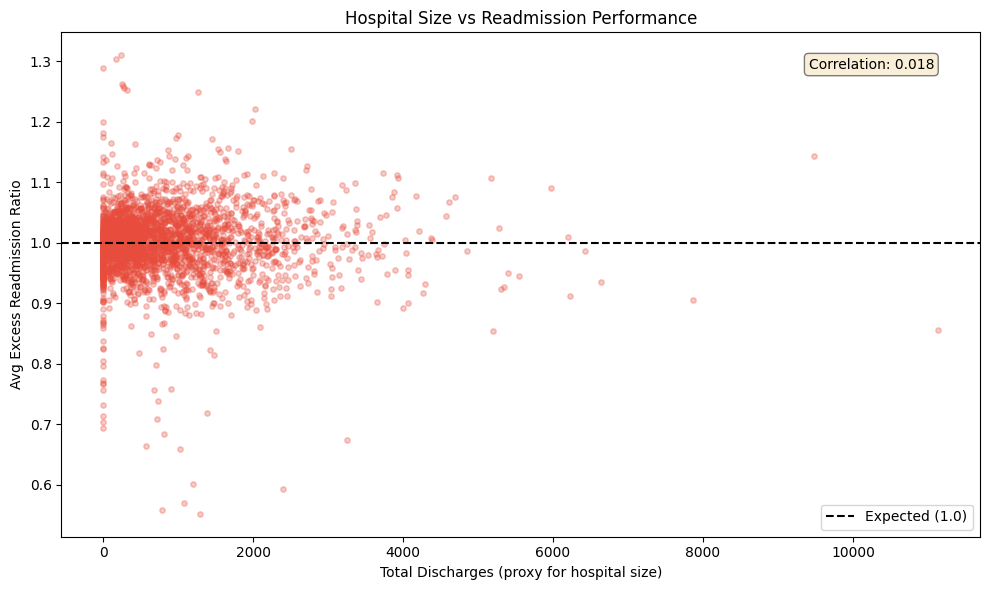

In [78]:
# chart 8: hospital size vs readmission performance
# using total discharges as a rough proxy for size
hosp_size = master[master['excess_readmission_ratio'].notna()].groupby('Facility ID').agg(
    total_discharges=('num_discharges', 'sum'),
    avg_err=('excess_readmission_ratio', 'mean')
).dropna()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(hosp_size['total_discharges'], hosp_size['avg_err'], alpha=0.3, s=15, c='#e74c3c')
ax.axhline(y=1.0, color='black', linestyle='--', label='Expected (1.0)')
ax.set_xlabel('Total Discharges (proxy for hospital size)')
ax.set_ylabel('Avg Excess Readmission Ratio')
ax.set_title('Hospital Size vs Readmission Performance')
corr = hosp_size['total_discharges'].corr(hosp_size['avg_err'])
ax.text(0.95, 0.95, f'Correlation: {corr:.3f}', transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.legend()
plt.tight_layout()
plt.savefig('charts/08_size_vs_err.png', dpi=150)
plt.show()

---
## saving sql queries + exporting for tableau

In [79]:
# save exploration queries to sql file
with open('sql/01_exploration.sql', 'w') as f:
    f.write("""-- data exploration queries
-- checking whats in each table and finding messy values

-- what measure types are in unplanned visits file?
SELECT [Measure ID], COUNT(*) as cnt 
FROM raw_unplanned_visits 
GROUP BY [Measure ID];

-- null ERR values in HRRP
SELECT [Excess Readmission Ratio], COUNT(*) as cnt
FROM raw_hrrp
WHERE [Excess Readmission Ratio] IS NULL 
GROUP BY [Excess Readmission Ratio];

-- messy scores in unplanned visits
SELECT Score, COUNT(*) as cnt
FROM raw_unplanned_visits
WHERE Score = 'Not Available' OR Score IS NULL
GROUP BY Score;

-- hospital counts across tables
SELECT 'hospital_info' as tbl, COUNT(DISTINCT [Facility ID]) as cnt FROM raw_hospital_info
UNION ALL
SELECT 'hrrp', COUNT(DISTINCT [Facility ID]) FROM raw_hrrp
UNION ALL
SELECT 'unplanned_visits', COUNT(DISTINCT [Facility ID]) FROM raw_unplanned_visits;

-- usable data per readmission measure
SELECT [Measure ID],
       COUNT(*) as total,
       SUM(CASE WHEN Score != 'Not Available' AND Score IS NOT NULL THEN 1 ELSE 0 END) as has_data,
       SUM(CASE WHEN Score = 'Not Available' OR Score IS NULL THEN 1 ELSE 0 END) as missing
FROM raw_unplanned_visits
WHERE [Measure ID] LIKE 'READM_30%'
GROUP BY [Measure ID];
""")
print('saved 01_exploration.sql')

saved 01_exploration.sql


In [80]:
# save cleaning queries
with open('sql/02_clean_data.sql', 'w') as f:
    f.write("""-- cleaning the messy CMS data
-- main issues: Not Available strings in numeric cols, need to filter measures

DROP TABLE IF EXISTS clean_hrrp;
CREATE TABLE clean_hrrp AS
SELECT 
    [Facility ID],
    [Facility Name],
    State,
    [Measure Name],
    CASE 
        WHEN [Excess Readmission Ratio] IS NULL THEN NULL
        WHEN [Excess Readmission Ratio] = '' THEN NULL
        ELSE CAST([Excess Readmission Ratio] AS REAL)
    END as excess_readmission_ratio,
    CASE
        WHEN [Number of Discharges] IS NULL THEN NULL
        WHEN [Number of Discharges] = '' THEN NULL
        ELSE CAST([Number of Discharges] AS INTEGER)
    END as num_discharges,
    CASE
        WHEN [Number of Readmissions] IS NULL THEN NULL
        ELSE CAST([Number of Readmissions] AS INTEGER)
    END as num_readmissions
FROM raw_hrrp;

DROP TABLE IF EXISTS clean_hospital_info;
CREATE TABLE clean_hospital_info AS
SELECT 
    [Facility ID],
    [Facility Name],
    [City/Town] as city,
    State,
    [ZIP Code],
    [County/Parish] as county,
    [Hospital Type],
    [Hospital Ownership],
    [Emergency Services],
    CASE 
        WHEN [Hospital overall rating] = 'Not Available' THEN NULL
        WHEN [Hospital overall rating] IS NULL THEN NULL
        ELSE CAST([Hospital overall rating] AS INTEGER)
    END as overall_rating,
    CASE
        WHEN [Hospital Ownership] LIKE '%non-profit%' THEN 'Non-Profit'
        WHEN [Hospital Ownership] LIKE '%Proprietary%' THEN 'For-Profit'
        WHEN [Hospital Ownership] LIKE '%Government%' THEN 'Government'
        WHEN [Hospital Ownership] LIKE '%Tribal%' THEN 'Tribal'
        ELSE 'Other'
    END as ownership_category
FROM raw_hospital_info;

-- only keeping the 6 readmission measures, not ED visits or other stuff
DROP TABLE IF EXISTS clean_readmissions;
CREATE TABLE clean_readmissions AS
SELECT 
    [Facility ID],
    [Facility Name],
    State,
    [Measure ID],
    [Measure Name],
    CASE 
        WHEN Score = 'Not Available' THEN NULL
        WHEN Score IS NULL THEN NULL
        ELSE CAST(Score AS REAL)
    END as readmission_rate,
    CASE 
        WHEN Denominator = 'Not Available' THEN NULL
        WHEN Denominator IS NULL THEN NULL
        ELSE CAST(Denominator AS INTEGER)
    END as num_discharges,
    [Compared to National]
FROM raw_unplanned_visits
WHERE [Measure ID] LIKE 'READM_30%';
""")
print('saved 02_clean_data.sql')

saved 02_clean_data.sql


In [81]:
# save join + analysis queries
with open('sql/03_join_and_analysis.sql', 'w') as f:
    f.write("""-- joining tables and running the actual analysis

-- master table
DROP TABLE IF EXISTS master_hospital;
CREATE TABLE master_hospital AS
SELECT 
    h.[Facility ID],
    h.[Facility Name],
    h.city,
    h.State,
    h.county,
    h.[Hospital Type],
    h.[Hospital Ownership],
    h.ownership_category,
    h.overall_rating,
    h.[Emergency Services],
    p.[Measure Name] as condition,
    p.excess_readmission_ratio,
    p.num_discharges,
    p.num_readmissions
FROM clean_hospital_info h
INNER JOIN clean_hrrp p ON h.[Facility ID] = p.[Facility ID];

-- avg ERR by condition
SELECT condition,
       COUNT(*) as hospitals_with_data,
       ROUND(AVG(excess_readmission_ratio), 4) as avg_err,
       SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) as num_above_expected,
       ROUND(100.0 * SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) / COUNT(*), 1) as pct_above
FROM master_hospital
WHERE excess_readmission_ratio IS NOT NULL
GROUP BY condition
ORDER BY avg_err DESC;

-- ownership comparison
SELECT ownership_category,
       COUNT(DISTINCT [Facility ID]) as num_hospitals,
       ROUND(AVG(excess_readmission_ratio), 4) as avg_err
FROM master_hospital
WHERE excess_readmission_ratio IS NOT NULL
GROUP BY ownership_category
ORDER BY avg_err DESC;

-- star rating vs ERR
SELECT overall_rating,
       COUNT(DISTINCT [Facility ID]) as num_hospitals,
       ROUND(AVG(excess_readmission_ratio), 4) as avg_err
FROM master_hospital
WHERE overall_rating IS NOT NULL
  AND excess_readmission_ratio IS NOT NULL
GROUP BY overall_rating
ORDER BY overall_rating;

-- worst offenders (failing 4+ conditions)
SELECT [Facility ID], 
       [Facility Name], 
       State, 
       ownership_category,
       overall_rating,
       COUNT(*) as conditions_measured,
       SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) as conditions_above_expected,
       ROUND(AVG(excess_readmission_ratio), 4) as avg_err
FROM master_hospital
WHERE excess_readmission_ratio IS NOT NULL
GROUP BY [Facility ID], [Facility Name], State, ownership_category, overall_rating
HAVING conditions_above_expected >= 4
ORDER BY conditions_above_expected DESC, avg_err DESC;

-- state level analysis
SELECT State,
       COUNT(DISTINCT [Facility ID]) as num_hospitals,
       ROUND(AVG(excess_readmission_ratio), 4) as avg_err
FROM master_hospital
WHERE excess_readmission_ratio IS NOT NULL
GROUP BY State
ORDER BY avg_err DESC;
""")
print('saved 03_join_and_analysis.sql')

saved 03_join_and_analysis.sql


In [82]:
# export processed data for tableau
os.makedirs('data/processed', exist_ok=True)
master.to_csv('data/processed/master_hospital.csv', index=False)

# also export the readmissions data with the national comparison
readm = pd.read_sql("SELECT * FROM clean_readmissions", conn)
readm.to_csv('data/processed/readmission_details.csv', index=False)

print(f'exported master_hospital.csv ({len(master)} rows)')
print(f'exported readmission_details.csv ({len(readm)} rows)')

exported master_hospital.csv (18330 rows)
exported readmission_details.csv (28734 rows)


## key findings summary

1. **For-profit hospitals have the highest excess readmission ratios** (avg ERR 1.0174) compared to non-profits (0.9984) and government hospitals (1.0012)

2. **Clear relationship between star rating and readmissions** - 1-star hospitals have avg ERR of 1.0415 while 5-star hospitals are at 0.9661

3. **Hip/Knee replacement** unexpectedly has the highest avg ERR among conditions at 1.0040 — surprising since its an elective procedure

4. About **48% of hospitals** have excess readmissions (ERR > 1.0) for any given condition

5. Some hospitals are failing on **all 6 conditions** - AdventHealth Orlando had the highest avg ERR (1.1426) among hospitals failing all 6

### TODO
- build tableau dashboard with these findings
- add the payment reduction data if i can find it (the HRRP file didnt have a penalty column)
- could do a regression to see which factors predict higher ERR
- look at trends over time (CMS publishes this data yearly)

In [83]:
conn.close()
print('done!')

done!
